<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - ([@fforster](https://github.com/fforster)) Francisco Förster: - **Main Notes 2026/01**   
>   - https://github.com/fforster/AS4501/tree/main
> - ([@thevalentino](https://github.com/thevalentino)) Valentino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - ([@cefuente](https://github.com/cefuente)) Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> 
> and previour teachers assistants
> - ([@m-fuentealba](https://github.com/m-fuentealba)) Melissa Fuentealba 
> - ([@jvines](https://github.com/jvines)) José Vines
> - ([@PauCaBu](https://github.com/PauCaBu)) Paula Cáceres Burgos
> - ([@JavieraTGrey](https://github.com/JavieraTGrey)) Javiera Toro Grey

In [66]:
import io
import warnings
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Astronomy 
from astroquery.sdss import SDSS

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

rc_params = {
    # --- Fonts and text ---
    'mathtext.fontset': 'cm',     # Set default mathtext font
    'font.family': 'STIXGeneral', # Set default font family
    
    # --- Figure and axes ---
    'font.size': 12,              # Set default font size
    'axes.labelsize': 16,         # Set default axes label size
    'axes.titlesize': 16,         # Set default axes title size
    'xtick.labelsize': 14,        # Set default axes label size
    'ytick.labelsize': 14,        # Set default axes label size
    'legend.fontsize': 14,        # Set default legend font size
    
    # --- Configuration of ticks ---
    'xtick.direction': 'in',      # Set default xtickdirecion
    'ytick.direction': 'in',      # Set default ytickdirecion
    'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
    'ytick.minor.visible': True,  # visibility of minor ticks on y-axis


    'grid.linestyle': ':',        # Set grid linestyle
    'grid.alpha': 0.6,            # Set grid transparency
    
    # --- Figure size ---
    'figure.figsize': (8, 6),     # Ideal proportion for one MNRAS column
}
plt.rcParams.update(rc_params)

# Manchas Solares y el Ciclo Solar
Las **manchas solares** son regiones de la fotosfera solar con temperatura más baja (~3500 K vs ~5800 K del entorno), causadas por la emergencia de campos magnéticos intensos que inhiben la convección local. Aunque son visibles a simple vista con filtros adecuados, su importancia va más allá de lo óptico: son el trazador más accesible de la actividad magnética solar.

El Sol no rota como un cuerpo rígido — su período de rotación varía entre ~25 días en el ecuador y ~35 días en los polos. Esta rotación diferencial estira y enreda las líneas de campo magnético, acumulando energía que se libera periódicamente en forma de manchas, llamaradas y eyecciones de masa coronal. El resultado es un ciclo de actividad magnética con período de aproximadamente **11 años**, conocido como el **Ciclo de Schwabe**.

El número de manchas solares (SSN, *SunSpot Number*) es la serie de tiempo astronómica continua más larga de la historia, con registros sistemáticos desde 1749 gracias al Observatorio de Zúrich y hoy mantenida por el SIDC. Esta continuidad la convierte en un laboratorio ideal para técnicas de análisis de series de tiempo:

- Su periodicidad dominante (~11 años) es lo suficientemente clara para ser detectada con Lomb-Scargle.
- Su amplitud variable ciclo a ciclo (el ciclo 19 alcanzó SSN~200, el ciclo 24 apenas ~100) hace que un modelo puramente periódico sea insuficiente, motivando el uso de Procesos Gaussianos con kernels quasi-periódicos.

In [16]:
url = "https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.txt"
df = pd.read_csv(
      url,
      sep=r"\s+",
      header=None,
      names=["year", "month", "frac_year", "ssn", "std", "nobs", "definitive"]
  )
df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))
df = df[["date", "ssn"]].rename(columns={"ssn": "intensity"})

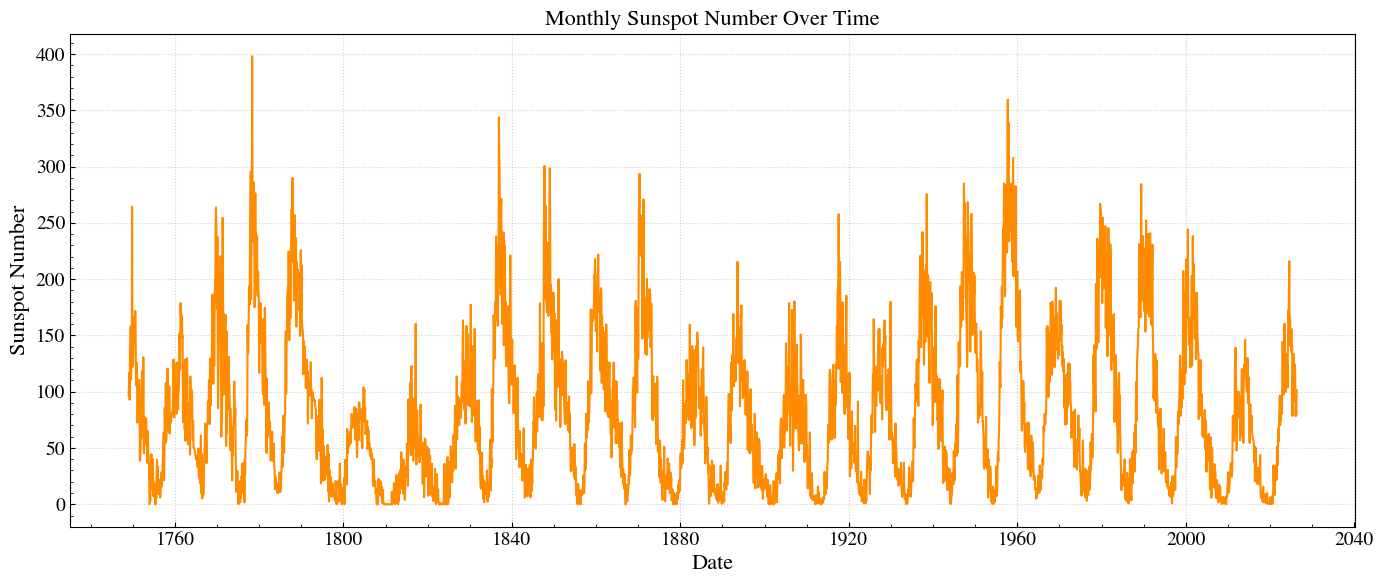

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["intensity"], color="darkorange")
plt.title("Monthly Sunspot Number Over Time")
plt.xlabel("Date")
plt.ylabel("Sunspot Number")
plt.grid()
plt.tight_layout()
plt.show()

In [21]:
df = df[df["intensity"] >= 0]  # eliminar valores faltantes (-1)
df = df.set_index("date")

Comparando con el notebook base del profesor, tu notebook cubre la parte GP pero omite conceptos que son prerequisito. Por orden de importancia para el tema solar:

Falta en Lomb-Scargle:

Visualizar el periodograma (potencia vs período) — no solo imprimir el peak
Probabilidad de falsa alarma (FAP) — para saber si el período detectado es estadísticamente significativo
Discutir el problema del aliasing y la ventana de muestreo (por eso aparecía 0.04 años)
Falta en GP:

Mostrar muestras del prior antes de ajustar — es la intro pedagógica estándar al GP
Extraer y reportar gp.kernel_.k1.k2.periodicity como resultado del período aprendido
Comparar el período de LS vs GP
Falta como contexto general:

ACF/PACF de la serie solar — muestra la estructura de correlación antes de modelar
Una celda de conclusión que responda: ¿cuál es el período del ciclo solar según tus dos métodos?
Sobre tu punto de que acotar LS es "trampa": tienes razón. La solución honesta no es acotar a mano, sino graficar el periodograma completo, ver que el pico principal es el alias mensual, y entonces introducir el concepto de ventana espectral como justificación — eso es contenido, no trampa.

In [22]:
df

,intensity
date,
1749-01-01,96.7
1749-02-01,104.3
1749-03-01,116.7
1749-04-01,92.8
1749-05-01,141.7
...,...
2026-01-01,112.5
2026-02-01,78.2
2026-03-01,85.9


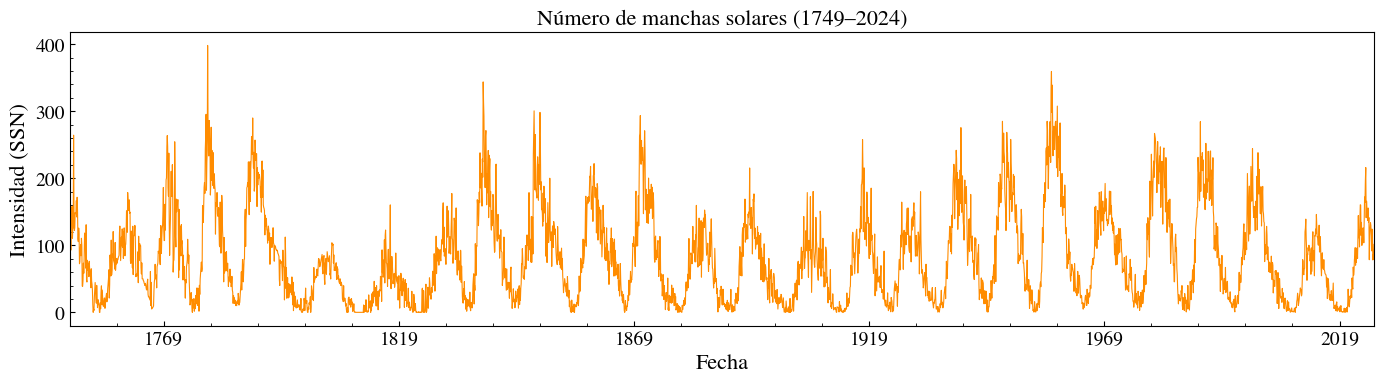

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
df["intensity"].plot(ax=ax, linewidth=0.8, color="darkorange")
ax.set_title("Número de manchas solares (1749–2024)")
ax.set_ylabel("Intensidad (SSN)")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.show()

In [24]:
from astropy.timeseries import LombScargle

In [25]:
t = (df.index - df.index[0]).total_seconds() / (365.25 * 24 * 3600)  # Convertir a años

frecuencia, potencia = LombScargle(t, df["intensity"]).autopower(
    minimum_frequency=1/20,   # períodos < 20 años
    maximum_frequency=1/5,    # períodos > 5 años
)
periodo_optimo = 1 / frecuencia[np.argmax(potencia)]

print(f"Período detectado: {periodo_optimo:.2f} años")

Período detectado: 10.98 años


Dado un conjunto de observaciones ${t_i, y_i}$, el periodograma de Lomb-Scargle a frecuencia $\omega = 2\pi f$ se define como:

$$P(\omega) = \frac{1}{2\hat{\sigma}^2} \left[ \frac{\left(\displaystyle\sum_i y_i \cos\omega(t_i - \tau)\right)^2}{\displaystyle\sum_i \cos^2\omega(t_i - \tau)} + \frac{\left(\displaystyle\sum_i y_i \sin\omega(t_i - \tau)\right)^2}{\displaystyle\sum_i \sin^2\omega(t_i - \tau)} \right]$$

donde $\hat{\sigma}^2 = \text{Var}(y)$ normaliza la potencia, y $\tau$ es el desfase de fase que hace al estimador invariante bajo traslación temporal:

$$\tan(2\omega\tau) = \frac{\displaystyle\sum_i \sin(2\omega t_i)}{\displaystyle\sum_i \cos(2\omega t_i)}$$

Con esta normalización, $P(\omega) \in [0, 1]$.

---
nterpretación geométrica del periodograma
Sea $\mathbf{y} = (y_1, \ldots, y_N)^T$ el vector de datos. El periodograma de Lomb-Scargle equivale a proyectar $\mathbf{y}$ sobre un subespacio sinusoidal. Definimos los vectores base (centrados, ortogonales por construcción de $\tau$):

$$\mathbf{c}\tau = \bigl(\cos\omega(t_i - \tau)\bigr)i, \qquad \mathbf{s}\tau = \bigl(\sin\omega(t_i - \tau)\bigr)i, \qquad \mathbf{c}\tau \perp \mathbf{s}\tau$$

Las proyecciones normalizadas de $\mathbf{y}$ sobre estos dos vectores son:

$$Z_c = \frac{\mathbf{y} \cdot \mathbf{c}\tau}{|\mathbf{c}\tau|} = \frac{\sum_i y_i \cos\omega(t_i-\tau)}{\sqrt{\sum_i \cos^2\omega(t_i-\tau)}}, \qquad Z_s = \frac{\mathbf{y} \cdot \mathbf{s}\tau}{|\mathbf{s}\tau|}$$

La potencia del periodograma es precisamente la norma cuadrada de esa proyección 2D, normalizada por la varianza:

$$P(\omega) = \frac{Z_c^2 + Z_s^2}{2,\hat{\sigma}^2}$$

Bajo $H_0$: los datos son ruido gaussiano
Si $H_0$ es verdadera, $y_i \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)$. Entonces $Z_c$ y $Z_s$ son combinaciones lineales de variables gaussianas — por lo tanto también gaussianas:

$$Z_c \sim \mathcal{N}(0,, \sigma^2), \qquad Z_s \sim \mathcal{N}(0,, \sigma^2)$$

y son independientes entre sí (porque $\mathbf{c}\tau \perp \mathbf{s}\tau$).

La suma de dos gaussianas cuadradas es $\chi^2_2$
Normalizando:

$$\frac{Z_c^2}{\sigma^2} \sim \chi^2_1, \qquad \frac{Z_s^2}{\sigma^2} \sim \chi^2_1$$

Su suma es:

$$\frac{Z_c^2 + Z_s^2}{\sigma^2} = 2,P(\omega) \cdot \frac{\sigma^2}{\hat{\sigma}^2} \xrightarrow{N\to\infty} 2,P(\omega) ;\sim; \chi^2_2$$

donde se usa $\hat{\sigma}^2 \to \sigma^2$ para $N$ grande.

$\chi^2_2$ es exactamente una distribución exponencial
La distribución $\chi^2_2$ tiene función de densidad:

$$f(x) = \tfrac{1}{2},e^{-x/2}, \quad x \geq 0$$

que es precisamente una exponencial con media 2. Por lo tanto, si $2z \sim \chi^2_2$:

$$\text{Pr}(2z > 2Z) = e^{-Z} \implies \boxed{\text{Pr}(z > Z \mid H_0) = e^{-Z}}$$

Resumen del argumento
$$\underbrace{y_i \sim \mathcal{N}(0,\sigma^2)}{\text{H}0} ;\Rightarrow; \underbrace{Z_c, Z_s \sim \mathcal{N}(0,\sigma^2) \text{ indep.}}{\text{ortogonalidad de } \tau} ;\Rightarrow; \underbrace{2P(\omega) \sim \chi^2_2}{\text{suma de 2 gaussianas}^2} ;\Rightarrow; \underbrace{P(z > Z) = e^{-Z}}_{\chi^2_2 \equiv \text{Exp}(1)}$$

Este resultado es exacto para muestreo regular en el límite $N \to \infty$, y una muy buena aproximación para datos reales. La desviación de este ideal (muestreo irregular, media no nula, errores heterocedásticos) es precisamente lo que motivó el método de Lomb-Scargle generalizado (Zechmeister & Kürster 2009).
---

La hipótesis nula $H_0$ es que los datos son ruido gaussiano puro (sin señal periódica). Bajo $H_0$, la potencia $z = P(\omega)$ en una frecuencia fija sigue una distribución exponencial:

$$\text{Pr}(z > Z \mid H_0) = e^{-Z}$$

Es decir, hay una probabilidad $e^{-Z}$ de observar una potencia mayor a $Z$ solo por azar en una sola frecuencia.

El periodograma evalúa $N_f$ frecuencias simultáneamente. La FAP es la probabilidad de que el máximo del periodograma supere el umbral $Z$ en al menos una frecuencia por azar:

$$\text{FAP}(Z) = \text{Pr}!\left(\max_j z_j > Z \mid H_0\right) = 1 - \text{Pr}!\left(\max_j z_j \leq Z \mid H_0\right)$$

Si las $M$ frecuencias fueran independientes:

$$\boxed{\text{FAP}(Z) = 1 - \left(1 - e^{-Z}\right)^M}$$

Para FAP pequeño ($e^{-Z} \ll 1$), esto aproxima a:

$$\text{FAP}(Z) \approx M \cdot e^{-Z}$$

La relación inversa — dado un umbral de FAP, ¿qué potencia $Z^*$ lo satisface? — es:

$$Z^* = -\ln!\left(1 - (1 - \text{FAP})^{1/M}\right)$$

Esto es lo que devuelve LombScargle.false_alarm_level([0.1, 0.01, 0.001]): la potencia mínima para que el pico sea significativo al 10%, 1%, 0.1%.

Para nuestros datos (3329 puntos mensuales desde 1749), obtuvimos:

$$\text{FAP}(z_{\max}) \approx 10^{-195}$$

Un valor tan extremo indica que el pico a $\sim$ 11 años es imposiblemente improbable bajo $H_0$ — la señal periódica solar es inconfundible en 277 años de datos.

In [34]:
potencia_max = potencia.max()
# False alarm probability
fap = LombScargle(t, df["intensity"]).false_alarm_probability(potencia_max)
print(f"False Alarm Probability: {fap:.2e}")

niveles = [0.1,0.01, 0.001]
fap_levels = LombScargle(t, df["intensity"]).false_alarm_level(niveles)
for nivel, fap_level in zip(niveles, fap_levels):
    print(f"Nivel de potencia para FAP={nivel * 100:.1f}%: {fap_level:.2f}")

False Alarm Probability: 1.57e-195
Nivel de potencia para FAP=10.0%: 0.01
Nivel de potencia para FAP=1.0%: 0.01
Nivel de potencia para FAP=0.1%: 0.01


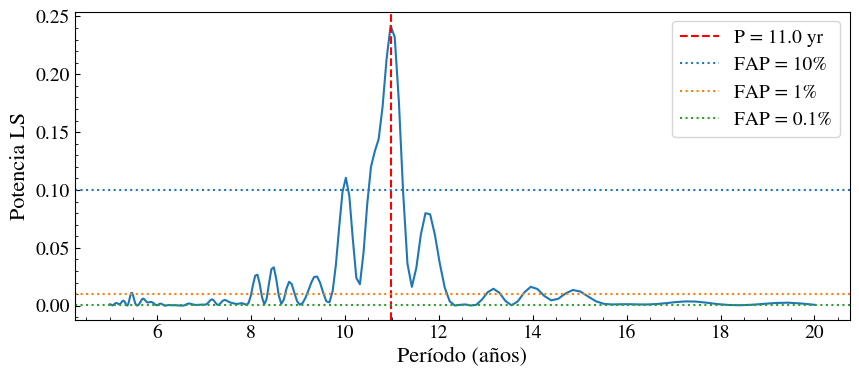

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(1 / frecuencia, potencia)
ax.axvline(periodo_optimo, color="red", ls="--", label=f"P = {periodo_optimo:.1f} yr")

for i, (nivel, fap_valin) in enumerate(zip(niveles, ["10%", "1%", "0.1%"])):
    ax.axhline(nivel, ls=":", color=f'C{i}', label=f"FAP = {fap_valin}")

ax.set_xlabel("Período (años)")
ax.set_ylabel("Potencia LS")
ax.legend()


In [61]:
# ---- Preparation -----
X_all = t.values.reshape(-1, 1)[::10]
y_all = df["intensity"].values[::10]

# Split into training and testing sets (80% train, 20% test)
# Option A: This split is for the interpolation task, where we want to predict the intensity at the original time points
X_train_inter, X_test_inter, y_train_inter, y_test_inter = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# Option B: This split is for the forecasting task, where we want to predict future values beyond the original time points
X_train_extrap, X_test_extrap, y_train_extrap, y_test_extrap = train_test_split(
    X_all, y_all, test_size=0.2, shuffle=False
)

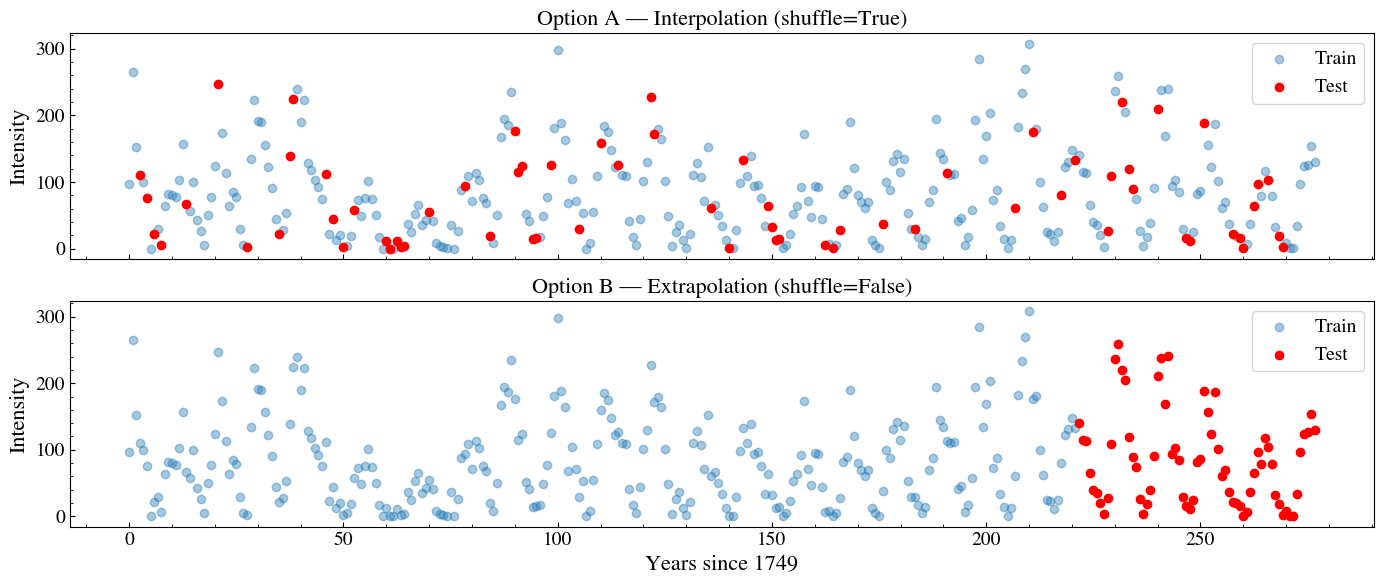

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Option A — Interpolation
axes[0].scatter(X_train_inter, y_train_inter, alpha=0.4, color="C0", label="Train")
axes[0].scatter(X_test_inter,  y_test_inter,  color="red", zorder=3, label="Test")
axes[0].set_title("Option A — Interpolation (shuffle=True)")
axes[0].set_ylabel("Intensity")
axes[0].legend()

# Option B — Extrapolation
axes[1].scatter(X_train_extrap, y_train_extrap, alpha=0.4, color="C0", label="Train")
axes[1].scatter(X_test_extrap,  y_test_extrap,  color="red", zorder=3, label="Test")
axes[1].set_title("Option B — Extrapolation (shuffle=False)")
axes[1].set_ylabel("Intensity")
axes[1].set_xlabel("Years since 1749")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, WhiteKernel

warnings.filterwarnings("ignore")

tcsv = TimeSeriesSplit(n_splits=5)

param_grid = [
    {"kernel": [RBF(length_scale=ls) for ls in [1.0, 10.0, 50.0, 100.0]]},
    {"kernel": [Matern(length_scale=ls, nu=nu)
                for ls in [1.0, 10.0, 50.0] for nu in [0.5, 1.5, 2.5]]},
    {"kernel": [ExpSineSquared(length_scale=ls, periodicity=p)
                for ls in [0.5, 1.0, 5.0] for p in [8.0, 11.0, 14.0]]},
    {"kernel": [RBF(length_scale=ls1) * ExpSineSquared(length_scale=ls2, periodicity=p)
                + WhiteKernel()
                for ls1 in [20.0, 50.0, 100.0]
                for ls2 in [0.5, 1.0, 5.0]
                for p   in [8.0, 11.0, 14.0]]},
]

gp_search = GaussianProcessRegressor(n_restarts_optimizer=3, normalize_y=True)
search = GridSearchCV(gp_search, param_grid, cv=tcsv,
                      scoring="neg_root_mean_squared_error", refit=True)
search.fit(X_train_extrap, y_train_extrap)

print(f"Mejor kernel: {search.best_params_['kernel']}")
print(f"Mejor RMSE CV: {-search.best_score_:.2f}")

warnings.resetwarnings()

Mejor kernel: Matern(length_scale=1, nu=1.5)
Mejor RMSE CV: 66.18


In [70]:
y_pred_ext, y_std_ext = search.best_estimator_.predict(X_test_extrap, return_std=True)
rmse_ext       = np.sqrt(np.mean((y_pred_ext - y_test_extrap)**2))
sigma_ext      = np.mean(np.abs(y_pred_ext - y_test_extrap) < 2 * y_std_ext)
print(f"RMSE en extrapolación: {rmse_ext:.2f}")

RMSE en extrapolación: 69.29


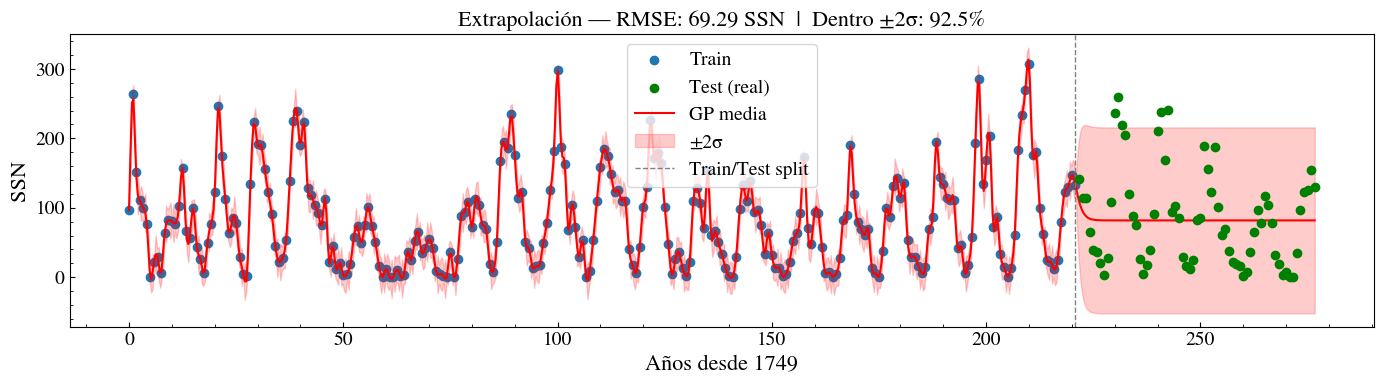

In [74]:
X_pred = np.linspace(X_all.min(), X_all.max(), 800).reshape(-1, 1)
y_mu, y_s = search.best_estimator_.predict(X_pred, return_std=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(X_train_extrap, y_train_extrap, color="C0", label="Train")
ax.scatter(X_test_extrap,  y_test_extrap, color="green", zorder=3, label=f"Test (real)")
ax.plot(X_pred, y_mu, color="red", lw=1.5, label="GP media")
ax.fill_between(X_pred.ravel(), y_mu - 2*y_s, y_mu + 2*y_s,
                alpha=0.2, color="red", label="±2σ")
ax.axvline(X_train_extrap.max(), color="gray", ls="--", lw=1, label="Train/Test split")
ax.set_xlabel("Años desde 1749")
ax.set_ylabel("SSN")
ax.set_title(f"Extrapolación — RMSE: {rmse_ext:.2f} SSN  |  Dentro ±2σ: {sigma_ext:.1%}")
ax.legend()
plt.tight_layout()
plt.show()

In [76]:
gp_inter = GaussianProcessRegressor(kernel=search.best_params_["kernel"], n_restarts_optimizer=5, normalize_y=True)
gp_inter.fit(X_train_inter, y_train_inter)
y_pred_int, y_std_int = gp_inter.predict(X_test_inter, return_std=True)

rmse_int       = np.sqrt(np.mean((y_pred_int - y_test_inter)**2))
sigma_int      = np.mean(np.abs(y_pred_int - y_test_inter) < 2 * y_std_int)
print(f"RMSE en interpolación: {rmse_int:.2f} SSN")
print(f"Porcentaje de puntos dentro de ±2σ en interpolación: {sigma_int:.1%}")

RMSE en interpolación: 31.39 SSN
Porcentaje de puntos dentro de ±2σ en interpolación: 94.0%


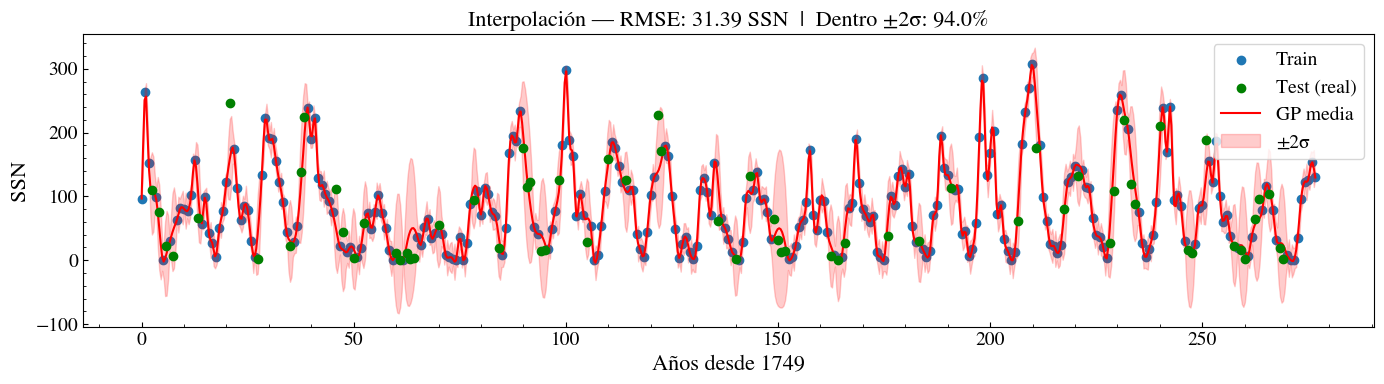

Kernel optimizado: Matern(length_scale=1.37, nu=1.5)


AttributeError: 'Matern' object has no attribute 'k1'

In [79]:
X_pred = np.linspace(X_all.min(), X_all.max(), 800).reshape(-1, 1)
y_mu, y_s = gp_inter.predict(X_pred, return_std=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(X_train_inter, y_train_inter, color="C0", label="Train")
ax.scatter(X_test_inter,  y_test_inter, color="green", zorder=3, label=f"Test (real)")
ax.plot(X_pred, y_mu, color="red", lw=1.5, label="GP media")
ax.fill_between(X_pred.ravel(), y_mu - 2*y_s, y_mu + 2*y_s,
                alpha=0.2, color="red", label="±2σ")
ax.set_xlabel("Años desde 1749")
ax.set_ylabel("SSN")
ax.set_title(f"Interpolación — RMSE: {rmse_int:.2f} SSN  |  Dentro ±2σ: {sigma_int:.1%}")
ax.legend()
plt.tight_layout()
plt.show()
print("Kernel optimizado:", gp_inter.kernel_)
periodo_gp = gp_inter.kernel_.k1.k2.periodicity
print(f"Período GP:           {periodo_gp:.2f} años")
print(f"Período Lomb-Scargle: {periodo_optimo:.2f} años")
print(f"Diferencia:           {abs(periodo_gp - periodo_optimo):.2f} años")